# Hohmann Transfer Extended to Lunar Gravity Capture (Numba)

本笔记本在标准 Hohmann 转移基础上，加入月球引力，继续模拟：
1. 地月转移漂泊段
2. 近月段动力学
3. 可选 LOI 冲量捕获（impulsive lunar orbit insertion）

代码来源：`cislunar_hohmann_numba_solver.py`。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cislunar_hohmann_numba_solver import (
    HohmannConfig,
    CislunarConfig,
    simulate_hohmann_numba,
    simulate_cislunar_capture_numba,
    generate_reference_orbits,
    build_animation_data,
)


In [2]:
# 1) baseline two-body Hohmann
hcfg = HohmannConfig(mu=3.986004418e14, r1=7000e3, r2=42164e3, dt=5.0)
hout = simulate_hohmann_numba(hcfg)

print('Baseline Hohmann (two-body) analytic:')
for k, v in hout['analytic'].items():
    if 'tof' in k:
        print(f'{k:28s}: {v:12.3f} s ({v/3600:.3f} h)')
    else:
        print(f'{k:28s}: {v:12.3f}')

# 2) cislunar mission timeline (includes lunar orbiting + descent + landing)
ccfg = CislunarConfig(enable_loi=True, dt=20.0)
out_full = build_animation_data(ccfg)

print() 
print('Cislunar summary (full timeline):')
for k, v in out_full['summary'].items():
    if isinstance(v, (bool, np.bool_)):
        print(f'{k:28s}: {bool(v)}')
    elif isinstance(v, float) and np.isnan(v):
        print(f'{k:28s}: nan')
    else:
        print(f'{k:28s}: {v:12.6f}')


Baseline Hohmann (two-body) analytic:
a_t                         : 24582000.000
v_circ_1                    :     7546.053
v_circ_2                    :     3074.666
v_peri_t                    :     9882.849
v_apo_t                     :     1640.735
dv1                         :     2336.796
dv2                         :     1433.931
dv_total                    :     3770.727
tof                         :    19178.154 s (5.327 h)

Cislunar summary (full timeline):
tof_hohmann_days            :     5.099490
dv1_ideal_m_s               :  2172.288642
dv1_used_m_s                :  2172.288642
moon_phase0_deg             :   122.807286
moon_soi_km                 : 66194.095392
closest_moon_distance_km    :  2217.760483
closest_moon_altitude_km    :   480.360483
closest_moon_time_day       :     4.644444
closest_earth_distance_km   : 12916.272600
collided_moon               : False
loi_burn_time_day           :     3.866204
loi_burn_dv_m_s             :   734.956881
final_lunar_specifi

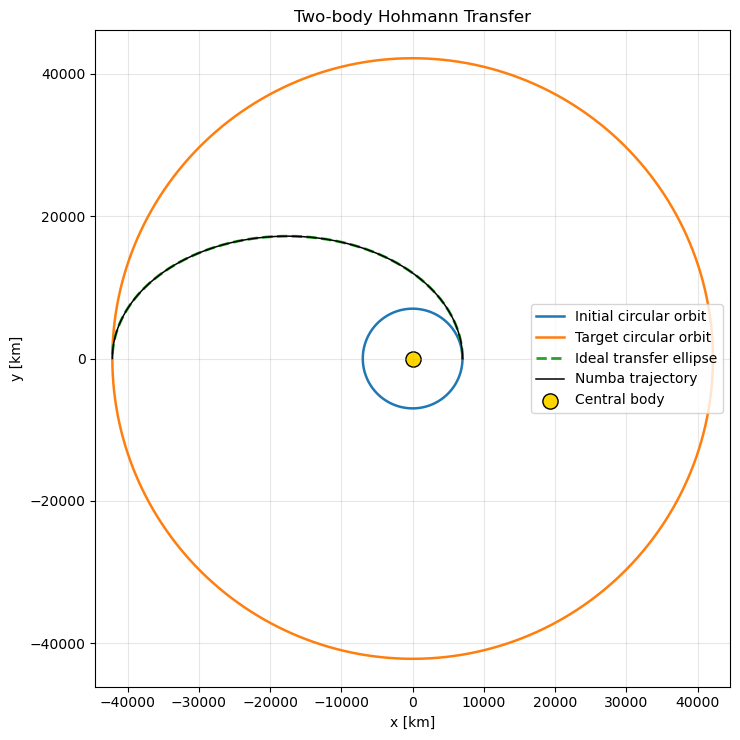

In [3]:
# Plot A: classic Hohmann geometry
_, c1, c2, tr = generate_reference_orbits(hcfg)
xy_h = hout['state'][:, :2]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.plot(c1[:,0]/1e3, c1[:,1]/1e3, lw=1.8, label='Initial circular orbit')
ax.plot(c2[:,0]/1e3, c2[:,1]/1e3, lw=1.8, label='Target circular orbit')
ax.plot(tr[:,0]/1e3, tr[:,1]/1e3, '--', lw=2.0, label='Ideal transfer ellipse')
ax.plot(xy_h[:,0]/1e3, xy_h[:,1]/1e3, color='k', lw=1.1, label='Numba trajectory')
ax.scatter([0], [0], s=120, c='gold', edgecolors='k', label='Central body')
ax.set_title('Two-body Hohmann Transfer')
ax.set_xlabel('x [km]')
ax.set_ylabel('y [km]')
ax.axis('equal')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Final |r_sc - r_moon_center| = 1737.400 km (Moon radius = 1737.400 km)


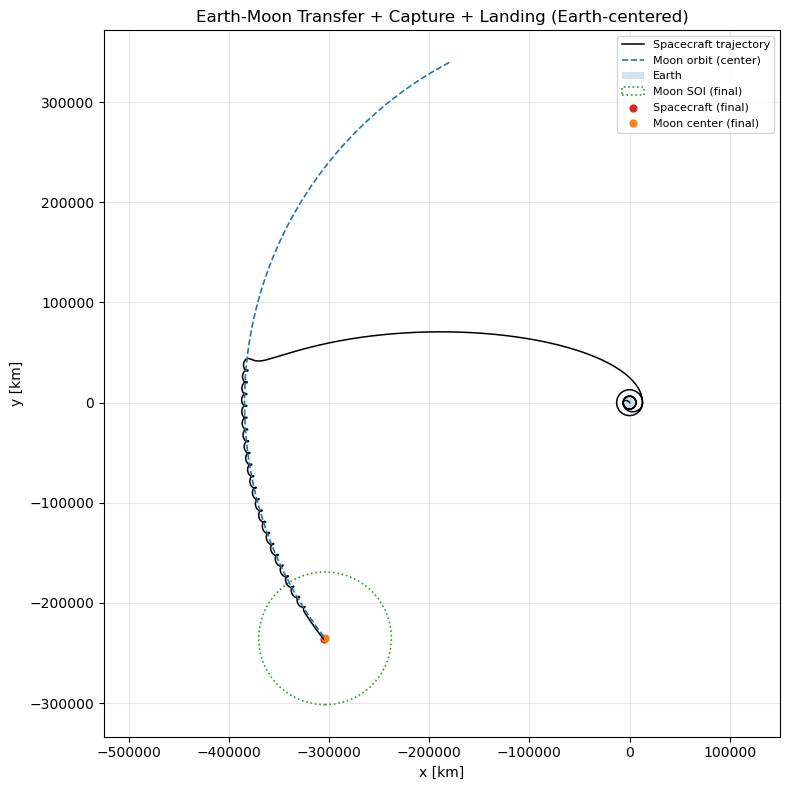

In [4]:
# Plot B: Earth-centered cislunar trajectory (full timeline)
sc = out_full['sc_xy_km']
mr = out_full['moon_xy_km']
phase = out_full['phase']

Re = ccfg.r_earth / 1e3
Rm = ccfg.r_moon / 1e3
Rsoi = out_full['summary']['moon_soi_km']

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(sc[:,0], sc[:,1], color='k', lw=1.1, label='Spacecraft trajectory')
ax.plot(mr[:,0], mr[:,1], '--', lw=1.2, label='Moon orbit (center)')

# Earth disk
th = np.linspace(0, 2*np.pi, 400)
ax.fill(Re*np.cos(th), Re*np.sin(th), alpha=0.2, label='Earth')

# Moon disk and SOI at final time
mx, my = mr[-1]
ax.add_patch(plt.Circle((mx, my), Rm, fill=False, lw=1.4, color='tab:orange'))
ax.add_patch(plt.Circle((mx, my), Rsoi, fill=False, ls=':', lw=1.2, color='tab:green', label='Moon SOI (final)'))

# Mark final spacecraft and moon-center positions from the SAME time index
d_sc_moon = np.linalg.norm(sc[-1] - mr[-1])
ax.scatter([sc[-1,0]], [sc[-1,1]], s=24, color='tab:red', label='Spacecraft (final)')
ax.scatter([mr[-1,0]], [mr[-1,1]], s=24, color='tab:orange', label='Moon center (final)')
print(f'Final |r_sc - r_moon_center| = {d_sc_moon:.3f} km (Moon radius = {Rm:.3f} km)')

ax.set_title('Earth-Moon Transfer + Capture + Landing (Earth-centered)')
ax.set_xlabel('x [km]')
ax.set_ylabel('y [km]')
ax.axis('equal')
ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


Final phase: Landing Complete
Final moon-centered distance = 1737.400 km (Moon radius = 1737.400 km)


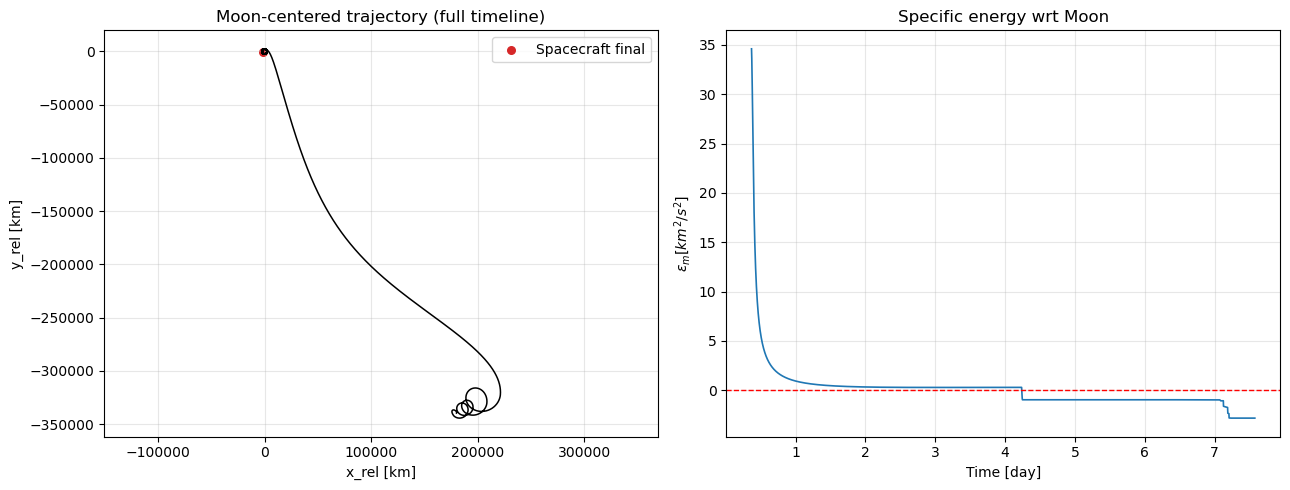

In [5]:
# Plot C: Moon-centered geometry using same-index Moon/spacecraft states
rel = sc - mr
t_day = out_full['t'] / 86400.0
eps = out_full['eps_m'] / 1e6  # km^2/s^2
phase = out_full['phase']

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].plot(rel[:,0], rel[:,1], lw=1.1, color='k')
axs[0].add_patch(plt.Circle((0, 0), Rm, fill=False, lw=1.4, color='tab:orange'))
axs[0].scatter([rel[-1,0]], [rel[-1,1]], s=30, color='tab:red', label='Spacecraft final')
axs[0].set_title('Moon-centered trajectory (full timeline)')
axs[0].set_xlabel('x_rel [km]')
axs[0].set_ylabel('y_rel [km]')
axs[0].axis('equal')
axs[0].grid(alpha=0.3)
axs[0].legend(loc='best')

axs[1].plot(t_day, eps, lw=1.2)
axs[1].axhline(0.0, color='r', ls='--', lw=1.0)
axs[1].set_title('Specific energy wrt Moon')
axs[1].set_xlabel('Time [day]')
axs[1].set_ylabel(r'$\epsilon_m [km^2/s^2]$')
axs[1].grid(alpha=0.3)

print(f'Final phase: {phase[-1]}')
print(f'Final moon-centered distance = {np.linalg.norm(rel[-1]):.3f} km (Moon radius = {Rm:.3f} km)')

plt.tight_layout()
plt.show()


## Notes

- `epsilon_m < 0` 表示相对月球为束缚轨道能量状态（满足捕获的必要条件）。
- 当前模型是二维平面、月球圆轨道近似、LOI 用瞬时冲量近似。